In [1]:
# Install packages if not already installed
if (!requireNamespace("BiocManager", quietly = TRUE))
    install.packages("BiocManager")

BiocManager::install("clusterProfiler")
BiocManager::install("org.Hs.eg.db")
BiocManager::install("enrichplot")
BiocManager::install("ggplot2")


'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.r-project.org

Bioconductor version 3.18 (BiocManager 1.30.22), R 4.3.3 (2024-02-29 ucrt)

Warning message:
"package(s) not installed when version(s) same as or greater than current; use
  `force = TRUE` to re-install: 'clusterProfiler'"
Installation paths not writeable, unable to update packages
  path: C:/Program Files/R/R-4.3.3/library
  packages:
    boot, class, cluster, codetools, foreign, KernSmooth, lattice, nlme, nnet,
    rpart, spatial, survival

Old packages: 'ape', 'aplot', 'askpass', 'backports', 'BH', 'BiocFileCache',
  'BiocManager', 'Biostrings', 'bit', 'bit64', 'broom', 'broom.helpers',
  'bslib', 'cachem', 'callr', 'classInt', 'cli', 'clue', 'colorspace', 'cpp11',
  'crayon', 'curl', 'data.table', 'DBI', 'dbplyr', 'digest', 'evaluate',
  'farver', 'fastmap', 'fastmatch', 'fontawesome', 'fs'

In [1]:
# Load necessary libraries
library(clusterProfiler)
library(org.Hs.eg.db)
library(ggplot2)
library(enrichplot)




clusterProfiler v4.10.1  For help: https://yulab-smu.top/biomedical-knowledge-mining-book/

If you use clusterProfiler in published research, please cite:
T Wu, E Hu, S Xu, M Chen, P Guo, Z Dai, T Feng, L Zhou, W Tang, L Zhan, X Fu, S Liu, X Bo, and G Yu. clusterProfiler 4.0: A universal enrichment tool for interpreting omics data. The Innovation. 2021, 2(3):100141


Attaching package: 'clusterProfiler'


The following object is masked from 'package:stats':

    filter


Loading required package: AnnotationDbi

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: 'BiocGenerics'


The following objects are masked from 'package:stats':

    IQR, mad, sd, var, xtabs


The following objects are masked from 'package:base':

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, 

In [2]:
# Load your datasets
upregulated_DEGs_24hrs <- read.csv("\\24hrs upregulated DEGs.csv", header = TRUE)
upregulated_DEGs_72hrs <- read.csv("\\72hrs upregulated DEGs.csv", header = TRUE)
upregulated_DEGs_120hrs <- read.csv("\\120hrs upregulated DEGs.csv", header = TRUE)

chemogenetics_sensitisation <- read.csv("\\Chemogenetics sensitisation list.csv", header = TRUE)

downregulated_DEGs_24hrs <- read.csv("\\24hrs downregulated DEGs.csv", header = TRUE)
downregulated_DEGs_72hrs <- read.csv("\\72hrs downregulated DEGs.csv", header = TRUE)
downregulated_DEGs_120hrs <- read.csv("\\120hrs downregulated DEGs.csv", header = TRUE)

chemogenetics_resistance <- read.csv("\\Chemogenetics resistance list.csv", header = TRUE)

# Load custom reference list
reference_genes_24hrs <- read.csv("\\24hrs reference list.csv", header = TRUE)
reference_genes_72hrs <- read.csv("\\72hrs reference list.csv", header = TRUE)
reference_genes_120hrs <- read.csv("\\120hrs reference list.csv", header = TRUE)

Chemogenetics_reference_list <- read.csv("\\Chemogenetics reference list.csv", header = TRUE)


In [3]:
# View the first few rows to check the structure
head(upregulated_DEGs_24hrs)
head(upregulated_DEGs_72hrs)
head(upregulated_DEGs_120hrs)
head(downregulated_DEGs_24hrs)
head(downregulated_DEGs_72hrs)
head(downregulated_DEGs_120hrs)
# Inspect the structure of the reference dataset
head(reference_genes_24hrs)
head(reference_genes_72hrs)
head(reference_genes_120hrs)

,Genes
,<chr>
1,ASF1B
2,YIPF2
3,MPDU1
4,TUB
5,ATP9B
6,CNNM3


,Genes
,<chr>
1,NUP85
2,NAA15
3,CEP170B
4,NUP107
5,GTF2IRD1
6,PYGB


,Genes
,<chr>
1,PRTFDC1
2,CPQ
3,CAPRIN2
4,TSHZ3
5,MICALL2
6,PHYH


,Genes
,<chr>
1,AC006011.1
2,TRABD2B
3,NPIPA8
4,AC127496.7
5,OPCML
6,CDKL3


,Genes
,<chr>
1,AC068547.1
2,AC058822.1
3,SNORD3B-2
4,CCDC87
5,ANKRD20A2
6,FLACC1


,Genes
,<chr>
1,AC034102.2
2,AC008764.4
3,AC058822.1
4,SLC22A1
5,PLGLB2
6,CFP


,Genes
,<chr>
1,PPP1R10
2,AC015813.6
3,TSPYL2
4,AC008581.2
5,AC006011.1
6,FP236241.1


,Genes
,<chr>
1,CD68
2,COLEC12
3,IL11
4,LNCAROD
5,TMTC2
6,PMP2


,Genes
,<chr>
1,FOS
2,MFAP4
3,JAG1
4,HCFC1R1
5,NRXN3
6,ZNF436


In [4]:
upregulated_go_24hrs <- enrichGO(
  gene          = upregulated_DEGs_24hrs$Genes,  
  OrgDb         = org.Hs.eg.db,
  keyType       = "SYMBOL",  
  ont           = "BP",      # Can be "BP" for Biological Process, "CC" for Cellular Component, or "MF" for Molecular Function
  pAdjustMethod = "BH",
  pvalueCutoff  = 0.05,
  qvalueCutoff  = 0.1,
  universe      = reference_genes_24hrs$Genes  
)


head(upregulated_go_24hrs)



ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>


In [6]:
upregulated_go_72hrs <- enrichGO(
  gene          = upregulated_DEGs_72hrs$Genes,  
  OrgDb         = org.Hs.eg.db,
  keyType       = "SYMBOL",  
  ont           = "BP",     
  pAdjustMethod = "BH",
  pvalueCutoff  = 0.05,
  qvalueCutoff  = 0.1,
  universe      = reference_genes_72hrs$Genes 
)


# View top results
head(upregulated_go_72hrs)



,ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>
GO:0006260,GO:0006260,DNA replication,49/649,276/14562,6.036054e-17,2.603954e-13,2.483042e-13,DNAJA3/CDK1/MCM3/ALYREF/CHAF1A/DNAJC2/FBXO5/TIMELESS/ZPR1/RRM2/PRIM2/DONSON/ESCO2/ACTL6A/GINS2/RFC5/ORC6/CDC7/RFWD3/CDC6/CHAF1B/TK1/RFC2/DSCC1/JADE1/CCNE2/CDC45/CDT1/RECQL4/BRCA1/USP37/BAZ1A/POLA2/RNASEH2A/GINS1/MCM8/FEN1/GRWD1/POLD4/DTL/POLD1/RFC4/TIPIN/TONSL/E2F7/PRIM1/TSPYL2/CHTF18/CCNE1,49
GO:0006261,GO:0006261,DNA-templated DNA replication,36/649,161/14562,5.110003e-16,1.102228e-12,1.051047e-12,DNAJA3/MCM3/ALYREF/FBXO5/TIMELESS/ZPR1/PRIM2/DONSON/GINS2/RFC5/ORC6/CDC7/RFWD3/CDC6/TK1/RFC2/DSCC1/CCNE2/CDC45/CDT1/RECQL4/BRCA1/BAZ1A/POLA2/GINS1/MCM8/FEN1/POLD4/POLD1/RFC4/TIPIN/TONSL/E2F7/PRIM1/CHTF18/CCNE1,36
GO:0016072,GO:0016072,rRNA metabolic process,38/649,257/14562,6.562595e-11,9.437012e-08,8.998815e-08,DDX18/BOP1/PA2G4/GEMIN4/FBL/GTF3C1/BMS1/NOP2/TSR1/UTP6/KRI1/NOP58/PPAN/RPF1/UTP4/RSL1D1/IMP4/PDCD11/EXOSC6/DDX54/RRP7A/RRS1/UTP11/DDX21/WDR43/TCOF1/PRKDC/LYAR/WDR74/POLR1E/NOLC1/DCAF13/NOC4L/RPF2/POLR1B/EMG1/BRIX1/DDX10,38
GO:0006364,GO:0006364,rRNA processing,34/649,222/14562,2.589343e-10,2.792606e-07,2.662935e-07,DDX18/BOP1/PA2G4/GEMIN4/FBL/BMS1/NOP2/TSR1/UTP6/KRI1/NOP58/PPAN/RPF1/UTP4/RSL1D1/IMP4/PDCD11/EXOSC6/DDX54/RRP7A/RRS1/UTP11/DDX21/WDR43/PRKDC/LYAR/WDR74/NOLC1/DCAF13/NOC4L/RPF2/EMG1/BRIX1/DDX10,34
GO:0042254,GO:0042254,ribosome biogenesis,40/649,316/14562,2.371874e-09,2.046453e-06,1.951428e-06,DDX18/BOP1/PA2G4/GEMIN4/GNL2/FBL/BMS1/NOP2/TSR1/UTP6/KRI1/NOP58/PPAN/RPF1/UTP4/NUP88/RSL1D1/IMP4/PDCD11/EXOSC6/DDX54/MYBBP1A/RRP7A/RRS1/UTP11/DDX21/WDR43/NLE1/PRKDC/LYAR/WDR74/GRWD1/NOLC1/DCAF13/NOC4L/MDN1/RPF2/EMG1/BRIX1/DDX10,40
GO:0007059,GO:0007059,chromosome segregation,44/649,392/14562,1.571058e-08,1.129590e-05,1.077139e-05,BCL7B/NUP43/CDK1/UBE2I/SPDL1/KNSTRN/HJURP/NTMT1/CHMP7/DYNC1LI1/CDCA5/MAP3K20/FBXO5/TOP2A/KNTC1/DRG1/STIL/FAM83D/ESCO2/ACTL6A/MAD2L2/ANAPC7/SPC24/CDC6/RRS1/MYBL2/CCNE2/CENPN/NCAPH2/CDT1/CHEK2/BRCA1/RCC1/PMF1/CLASP1/FANCD2/DSN1/CENPH/DCAF13/CENPU/HAUS8/TOP3B/CCNE1/MND1,44


In [8]:
upregulated_go_120hrs <- enrichGO(
  gene          = upregulated_DEGs_120hrs$Genes,  
  OrgDb         = org.Hs.eg.db,
  keyType       = "SYMBOL", 
  ont           = "BP",      
  pAdjustMethod = "BH",
  pvalueCutoff  = 0.05,
  qvalueCutoff  = 0.1,
  universe      = reference_genes_120hrs$Genes 
)


# View top results
head(upregulated_go_120hrs)



,ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>
GO:0030198,GO:0030198,extracellular matrix organization,39/761,296/15131,3.418941e-08,6.554481e-05,5.881857e-05,CCDC80/COL14A1/COL1A2/TGFB2/CCN1/CYP1B1/ECM2/COL11A1/NFKB2/MELTF/MMP15/LOXL4/CLASP1/FBLN1/SERAC1/OLFML2A/COL5A1/COL7A1/COL3A1/OLFML2B/NTN4/BMP2/CREB3L1/ADAMTS1/CHADL/FGFR4/SULF2/ADAMTSL4/FOXC2/COL24A1/CARMIL2/LOX/PTX3/FBLN5/DPT/FMOD/COL10A1/MFAP4/ABI3BP,39
GO:0043062,GO:0043062,extracellular structure organization,39/761,297/15131,3.751213e-08,6.554481e-05,5.881857e-05,CCDC80/COL14A1/COL1A2/TGFB2/CCN1/CYP1B1/ECM2/COL11A1/NFKB2/MELTF/MMP15/LOXL4/CLASP1/FBLN1/SERAC1/OLFML2A/COL5A1/COL7A1/COL3A1/OLFML2B/NTN4/BMP2/CREB3L1/ADAMTS1/CHADL/FGFR4/SULF2/ADAMTSL4/FOXC2/COL24A1/CARMIL2/LOX/PTX3/FBLN5/DPT/FMOD/COL10A1/MFAP4/ABI3BP,39
GO:0045229,GO:0045229,external encapsulating structure organization,39/761,298/15131,4.113691e-08,6.554481e-05,5.881857e-05,CCDC80/COL14A1/COL1A2/TGFB2/CCN1/CYP1B1/ECM2/COL11A1/NFKB2/MELTF/MMP15/LOXL4/CLASP1/FBLN1/SERAC1/OLFML2A/COL5A1/COL7A1/COL3A1/OLFML2B/NTN4/BMP2/CREB3L1/ADAMTS1/CHADL/FGFR4/SULF2/ADAMTSL4/FOXC2/COL24A1/CARMIL2/LOX/PTX3/FBLN5/DPT/FMOD/COL10A1/MFAP4/ABI3BP,39
GO:0001503,GO:0001503,ossification,46/761,390/15131,6.365207e-08,7.606422e-05,6.825847e-05,FOSL2/ANO6/COL1A2/CCN1/KLF10/FSTL3/COL11A1/LRP3/ITGA11/THBS3/DDX21/LRP4/RFLNB/ECM1/NOCT/PDLIM7/LTBP3/CRIM1/NOTUM/CCN2/ACHE/BMP2/SNAI2/CCN4/CEBPA/EPHA2/JUND/IGFBP3/FGFR2/CREB3L1/WNT7B/RRAS2/KREMEN2/FGFR3/TUFT1/FHL2/SLC8A1/IGF2/JAG1/FOXC2/LOX/ALPL/ERFE/HAND2/FBN2/OSTN,46
GO:0001525,GO:0001525,angiogenesis,52/761,494/15131,3.550152e-07,2.373365e-04,2.129809e-04,VEGFA/HK2/TGFB2/CCN1/ETS1/PLK2/CYP1B1/ERBB2/CLIC4/TSPAN12/CARD10/MCAM/AMOTL2/FN1/ECM1/GADD45A/CSPG4/SPHK1/RRAS/PDGFRB/SERPINE1/ACE/CCN2/NGFR/EPHB2/HTATIP2/EPHA2/CXCR4/SAT1/TNFRSF12A/NOTCH3/FGFR2/CREB3L1/NR4A1/PLXND1/ADAMTS1/PTPRM/UNC5B/NOTCH4/THBS1/HSPG2/JAG1/TGFA/KLF4/FOXC2/GPNMB/CTSH/APLN/NPR3/HAND2/EGR3/C3,52
GO:0030335,GO:0030335,positive regulation of cell migration,52/761,494/15131,3.550152e-07,2.373365e-04,2.129809e-04,FADD/VEGFA/PLP1/ANO6/SOD2/SEMA3C/TGFB2/CCN1/ETS1/PLK2/CYP1B1/EPHA4/PDGFD/MCAM/FN1/CLASP1/SPHK1/ABL2/SH3RF2/DAPK2/RRAS/PDGFRB/PREX1/SERPINE1/BMP2/SNAI2/EPHB2/NTRK3/SEMA5B/CCN4/ARHGEF2/EPHA2/CXCR4/FER/CEMIP/ADAMTS1/RRAS2/THBS1/WNT5B/CD274/ACTA2/FOXC2/GPNMB/CTSH/CARMIL2/SEMA3F/IL34/SEMA3B/LRRC15/HBEGF/PDGFB/CLDN1,52


In [10]:
downregulated_go_24hrs <- enrichGO(
  gene          = downregulated_DEGs_24hrs$Genes,  
  OrgDb         = org.Hs.eg.db,
  keyType       = "SYMBOL",
  ont           = "BP",
  pAdjustMethod = "BH",
  pvalueCutoff  = 0.05,
  qvalueCutoff  = 0.1,
  universe      = reference_genes_24hrs$Genes  
)
head(downregulated_go_24hrs)

,ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>
GO:0050795,GO:0050795,regulation of behavior,4/40,56/15016,1.43462e-05,0.01418839,0.01292668,GRPR/NLGN1/ARRDC3/ZFHX3,4


In [12]:
downregulated_go_72hrs <- enrichGO(
  gene          = downregulated_DEGs_72hrs$Genes,  
  OrgDb         = org.Hs.eg.db,
  keyType       = "SYMBOL",
  ont           = "BP",
  pAdjustMethod = "BH",
  pvalueCutoff  = 0.05,
  qvalueCutoff  = 0.1,
  universe      = reference_genes_72hrs$Genes  
)
head(downregulated_go_72hrs)

,ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>
GO:0061564,GO:0061564,axon development,45/639,478/14562,1.148035e-06,0.004766641,0.004674314,CTNNA2/PLXNA4/FLRT2/EFNB3/DISC1/ANOS1/PLP1/MAPT/MEGF8/MAP6/NRXN3/SEMA6A/RGMA/TRIM46/DCLK1/SEMA6C/CHL1/VASH2/TUBB3/ROBO2/BOC/GPM6B/NOVA2/NUMBL/LAMA2/BMPR1B/SEMA4B/EPHA3/PLXNB3/EPHB3/CDH11/MAPK8IP3/S100B/B4GAT1/NDP/FYN/SPAST/TUBB2B/C12orf57/ITGA4/CNR1/B4GALT5/RUFY3/NDN/CNP,45
GO:0007409,GO:0007409,axonogenesis,40/639,423/14562,4.090694e-06,0.008492281,0.008327792,CTNNA2/PLXNA4/FLRT2/EFNB3/DISC1/ANOS1/MAPT/MEGF8/MAP6/NRXN3/SEMA6A/RGMA/TRIM46/DCLK1/SEMA6C/CHL1/TUBB3/ROBO2/BOC/NOVA2/NUMBL/LAMA2/BMPR1B/SEMA4B/EPHA3/PLXNB3/EPHB3/CDH11/S100B/B4GAT1/NDP/FYN/SPAST/TUBB2B/C12orf57/ITGA4/B4GALT5/RUFY3/NDN/CNP,40
GO:0022010,GO:0022010,central nervous system myelination,7/639,22/14562,2.902840e-05,0.027890943,0.027350717,KCNJ10/PLP1/TENM4/GPM6B/NCSTN/ID4/B4GALT5,7
GO:0032291,GO:0032291,axon ensheathment in central nervous system,7/639,22/14562,2.902840e-05,0.027890943,0.027350717,KCNJ10/PLP1/TENM4/GPM6B/NCSTN/ID4/B4GALT5,7
GO:0018243,GO:0018243,protein O-linked glycosylation via threonine,5/639,10/14562,3.358736e-05,0.027890943,0.027350717,GALNT16/GALNT4/GALNT1/GALNT2/GALNT11,5
GO:0098742,GO:0098742,cell-cell adhesion via plasma-membrane adhesion molecules,25/639,237/14562,4.533279e-05,0.031370289,0.030762670,PCDHA9/PCDHGA2/PCDHA1/PCDHA4/NLGN1/PCDHA10/TENM1/SDK1/PCDHGA4/TENM4/TENM3/SPARCL1/PCDHGB2/PCDHGA9/CRB1/ROBO2/CLSTN3/IGSF11/MAP2K5/ADGRL3/TRO/PLXNB3/CDH11/LRRC4B/TENM2,25


In [14]:
downregulated_go_120hrs <- enrichGO(
  gene          = downregulated_DEGs_120hrs$Genes,  
  OrgDb         = org.Hs.eg.db,
  keyType       = "SYMBOL",
  ont           = "BP",
  pAdjustMethod = "BH",
  pvalueCutoff  = 0.05,
  qvalueCutoff  = 0.1,
  universe      = reference_genes_120hrs$Genes 
)
head(downregulated_go_120hrs)

ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>


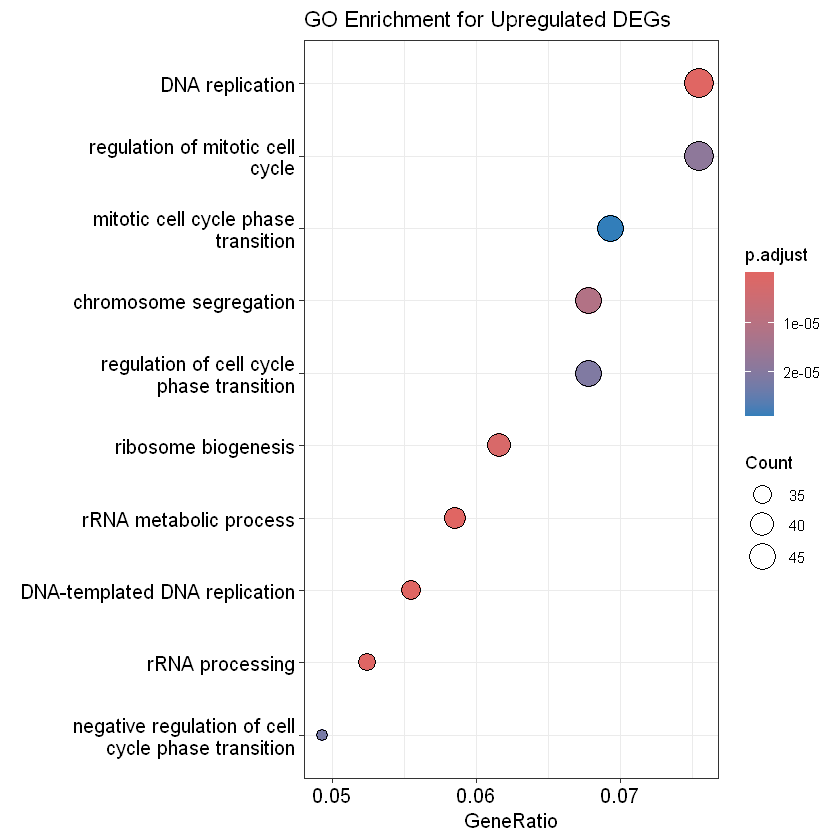

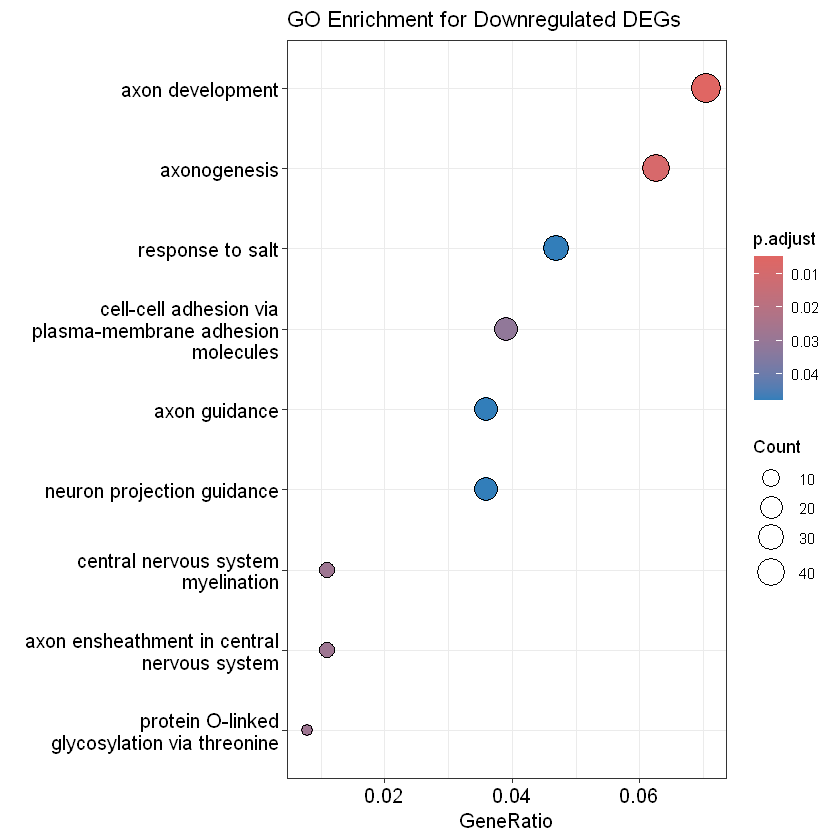

In [89]:
dotplot(upregulated_go_72hrs, showCategory = 10, title = "GO Enrichment for Upregulated DEGs") + scale_color_gradient(low = "#EA7500", high = "#a1a1a1") 


dotplot(downregulated_go_72hrs, showCategory = 10, title = "GO Enrichment for Downregulated DEGs")


In [29]:
jpeg("upregulated_GO_barplot.jpeg", width = 800, height = 600, res = 72)

barplot(upregulated_go, showCategory = 10, title = "GO Enrichment for Upregulated DEGs")

dev.off()

jpeg("downregulated_GO_dotplot.jpeg", width = 800, height = 600, res = 72)

dotplot(downregulated_go, showCategory = 10, title = "GO Enrichment for Downregulated DEGs")

dev.off()


png 
  2

png 
  2

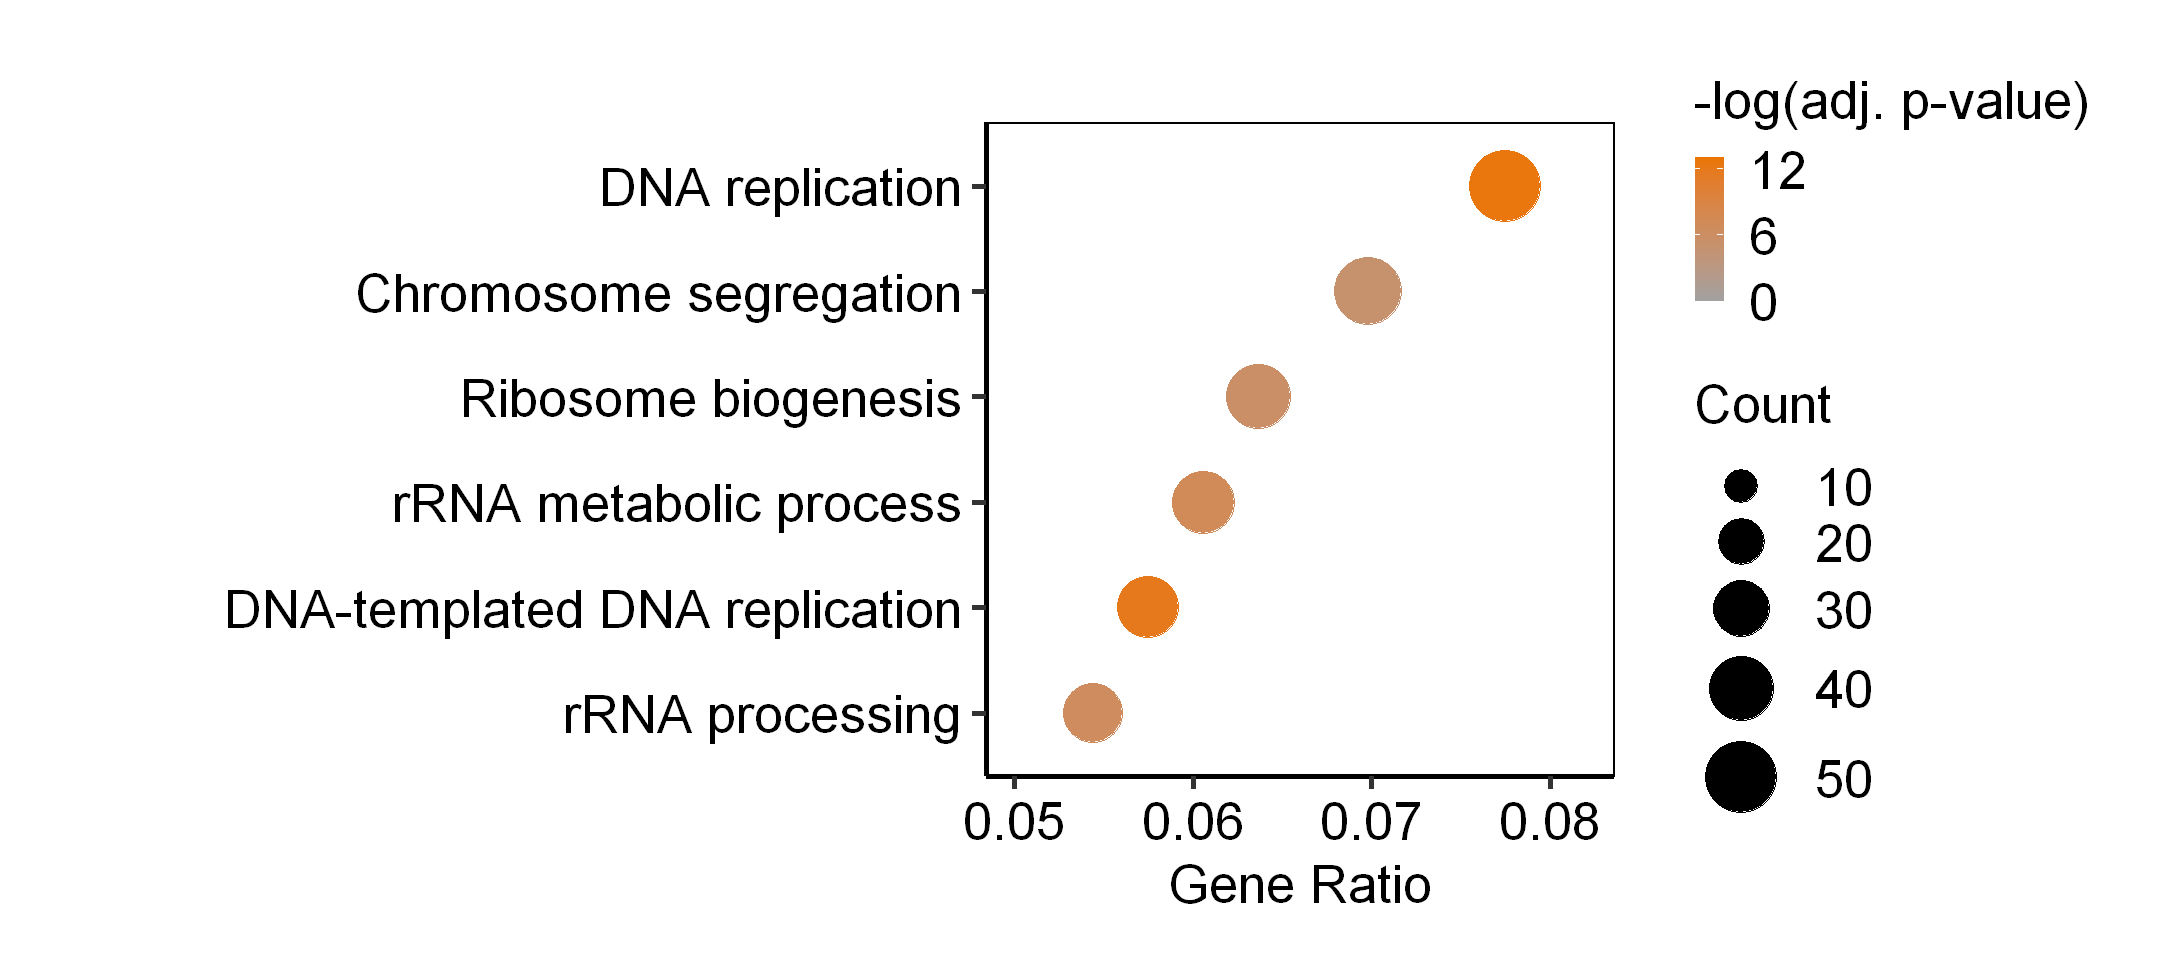

In [61]:
library(scales)
options(repr.plot.width = 18, repr.plot.height = 8)
size=32

go_data <- head(as.data.frame(upregulated_go_72hrs), 6)
go_data$Description <- c("DNA replication", "DNA-templated DNA replication", "rRNA metabolic process",
                         "rRNA processing","Ribosome biogenesis","Chromosome segregation")

go_data$GeneRatio <- sapply(strsplit(as.character(go_data$GeneRatio), "/"), function(x) as.numeric(x[1]) / as.numeric(x[2]))

ggplot(go_data, aes(x = GeneRatio, y = reorder(Description, GeneRatio), size = Count, color = -log10(p.adjust))) +
  geom_point() +
  
  scale_color_gradient(low = "#A1A1A1", high = "#EA7500", limits = c(0, 13), 
                       breaks = c(0, 6, 12)) +  # Set ticks at 0, 4, 8, 12
  
  scale_x_continuous(limits = c(0.048, 0.08), breaks = seq(0.048, 0.08, by = 0.01),
                     labels = scales::label_number(accuracy = 0.01)) + 

  
  theme_classic(base_size=size) +
  
  theme(panel.border = element_rect(color = "black", fill = NA, linewidth = 1),  
        legend.title = element_text(margin = margin(b = 20), size = size, color = "black"), 
        legend.text = element_text(size=size),
        legend.spacing = unit(0.5, "cm"),  
        text = element_text(family = "sans", size = size, color = "black"),
        
        axis.text = element_text(family = "sans", size = size, color = "black"),
        
        axis.title.y = element_text(margin = margin(r = 20), size = size, color = "black"), 
        
        plot.title = element_text(family = "sans", size = size, face = "bold", color = "black"),
        
        plot.margin = margin(1, 1, 1, 3, "cm")) +  
    
  labs(title = "",
       x = "Gene Ratio", 
       y = "",
       color = "-log(adj. p-value)") +
  
  scale_size_continuous(range = c(1, 20), limits = c(1,50), breaks = c(10, 20, 30, 40, 50))

ggsave("72hrs_up_dot_plot_GO.jpeg", width = 18, height = 8, dpi = 300)


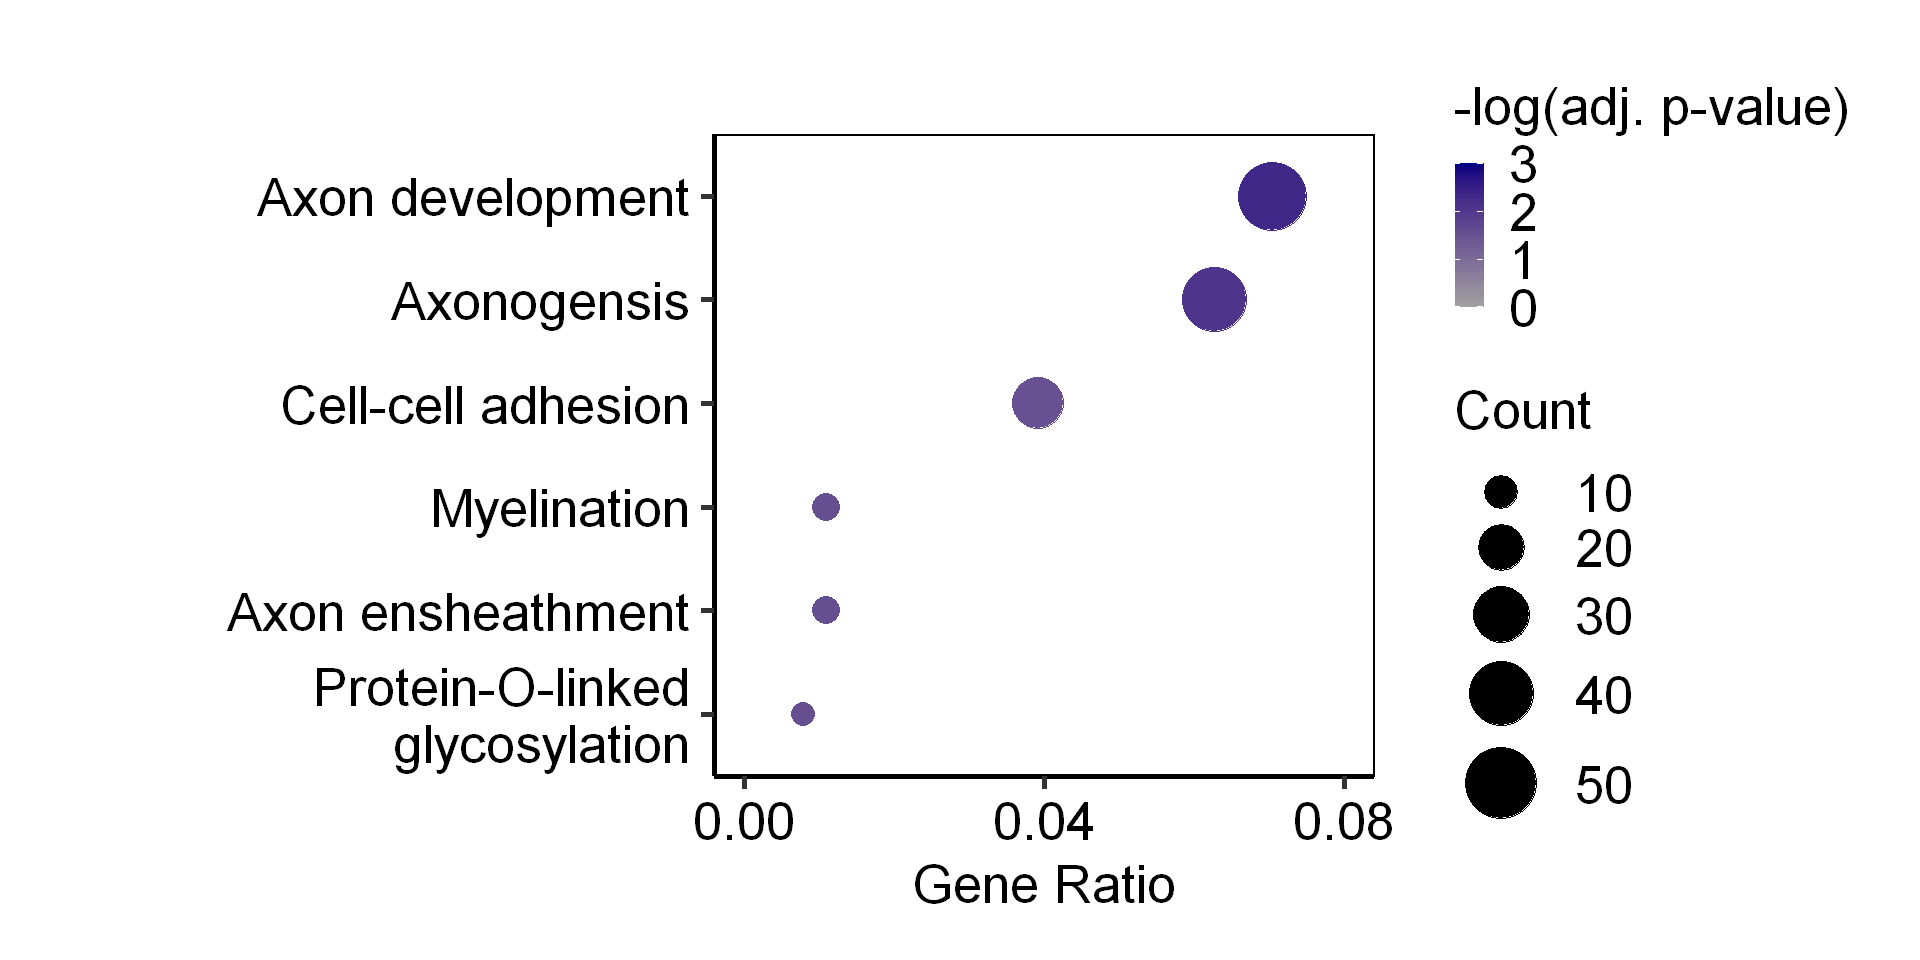

In [135]:
library(scales)
options(repr.plot.width = 16, repr.plot.height = 8)
size=32

go_data <- head(as.data.frame(downregulated_go_72hrs), 6)
go_data$Description <- c("Axon development", "Axonogensis","Myelination","Axon ensheathment","Protein-O-linked\nglycosylation","Cell-cell adhesion")

go_data$GeneRatio <- sapply(strsplit(as.character(go_data$GeneRatio), "/"), function(x) as.numeric(x[1]) / as.numeric(x[2]))

ggplot(go_data, aes(x = GeneRatio, y = reorder(Description, GeneRatio), size = Count, color = -log10(p.adjust))) +
  geom_point() +
  
  scale_color_gradient(low = "#A1A1A1", high = "#00007F", limits = c(0, 3), 
                       breaks = c(0, 1,2,3)) + 
  
  scale_x_continuous(limits = c(0.0, 0.08), breaks = seq(0.0, 0.08, by = 0.04),
                     labels = scales::label_number(accuracy = 0.01)) +  
                          
  theme_classic(base_size=size) +
  
  theme(panel.border = element_rect(color = "black", fill = NA, linewidth = 1),  

        legend.title = element_text(family = "sans", color = "black", size = size, margin = margin(b = 20)),
        legend.text = element_text(size = size),
        legend.spacing = unit(0.5, "cm"), 

  
        text = element_text(family = "sans", size = size, color = "black"),
        
        axis.text = element_text(family = "sans", size = size, color = "black"),
        
        axis.title.y = element_text(margin = margin(r = 20), color = "black"),
        
        plot.title = element_text(family = "sans", face = "bold", color = "black"),
        
        plot.margin = margin(1, 1, 1, 3, "cm")) + 
    
  labs(title = "",
       x = "Gene Ratio", 
       y = "",
       color = "-log(adj. p-value)") +
  
  scale_size_continuous(range = c(1, 20), limits = c(1,50), breaks = c(10, 20, 30, 40, 50))


    ggsave("72hrs_down_dot_plot_GO.jpeg", width = 16, height = 8, dpi = 300)


In [7]:
chemogenetic_go_sensitisation <- enrichGO(
  gene          = chemogenetics_sensitisation$Genes,  
  OrgDb         = org.Hs.eg.db,
  keyType       = "SYMBOL", 
  ont           = "BP",     
  pAdjustMethod = "BH",
  pvalueCutoff  = 0.05,
  qvalueCutoff  = 0.1,
  universe      = Chemogenetics_reference_list$Genes  
)


head(chemogenetic_go_sensitisation)


,ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>
GO:0022613,GO:0022613,ribonucleoprotein complex biogenesis,35/576,407/15257,5.131591e-06,0.01602922,0.01596158,NPM1/XPO1/POLR2D/EBNA1BP2/METTL16/CD2BP2/RPP40/NOP58/MCTS1/POP7/WDR12/RRP12/SRSF1/SF3B3/MPHOSPH10/WDR75/SF3A1/YTHDC1/USP36/RPL7/EIF2D/KRI1/HTATSF1/PRKRA/NOL3/NVL/RPS14/RPS9/LSG1/RUVBL1/SNRPF/DDX31/CPSF7/RRP8/EIF1AX,35
GO:0006397,GO:0006397,mRNA processing,36/576,432/15257,7.627514e-06,0.01602922,0.01596158,RBMXL1/NPM1/SMU1/ZMAT5/SRSF3/POLR2D/METTL16/CD2BP2/KIN/THOC3/WDR33/BUD31/NSRP1/CDC5L/SON/SRSF1/SF3B3/HNRNPA0/RBM7/TRUB2/SF3A1/YTHDC1/FAM50A/RBM8A/RBM42/HTATSF1/NOL3/ZNF326/SNRNP70/SRSF11/SYNCRIP/PRPF40A/PRPF38B/SNRPF/ECD/CPSF7,36


In [9]:
chemogenetic_go_resistance <- enrichGO(
  gene          = chemogenetics_resistance$Genes, 
  OrgDb         = org.Hs.eg.db,
  keyType       = "SYMBOL",  
  ont           = "BP",      
  pAdjustMethod = "BH",
  pvalueCutoff  = 0.05,
  qvalueCutoff  = 0.1,
  universe      = Chemogenetics_reference_list$Genes 
)


# View top results
head(chemogenetic_go_resistance)

,ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>
GO:0008380,GO:0008380,RNA splicing,21/257,405/15257,5.246460e-06,0.01586529,0.01580013,WDR77/SNRPE/LSM6/FAM98A/TARDBP/CWC25/PUS7/WBP4/MBNL1/SNW1/RBM4B/SREK1IP1/FRG1/HNRNPH2/ELAVL4/ATXN7/GEMIN5/GEMIN4/MYOD1/PQBP1/TRPT1,21
GO:0006399,GO:0006399,tRNA metabolic process,12/257,164/15257,2.194437e-05,0.03310246,0.03296649,OSGEP/MARS2/LSM6/FAM98A/TRIT1/PUS7/AARSD1/ELP2/HSD17B10/DUS2/TRPT1/GTPBP3,12
GO:0008033,GO:0008033,tRNA processing,10/257,119/15257,3.283974e-05,0.03310246,0.03296649,OSGEP/LSM6/FAM98A/TRIT1/PUS7/ELP2/HSD17B10/DUS2/TRPT1/GTPBP3,10
GO:0006397,GO:0006397,mRNA processing,20/257,432/15257,4.499617e-05,0.03401710,0.03387738,WDR77/SNRPE/LSM6/RPUSD3/TARDBP/CWC25/PUS7/WBP4/MBNL1/SNW1/RBM4B/SREK1IP1/FRG1/ELAVL4/RPRD1A/GEMIN5/GEMIN4/MYOD1/RNMT/PQBP1,20


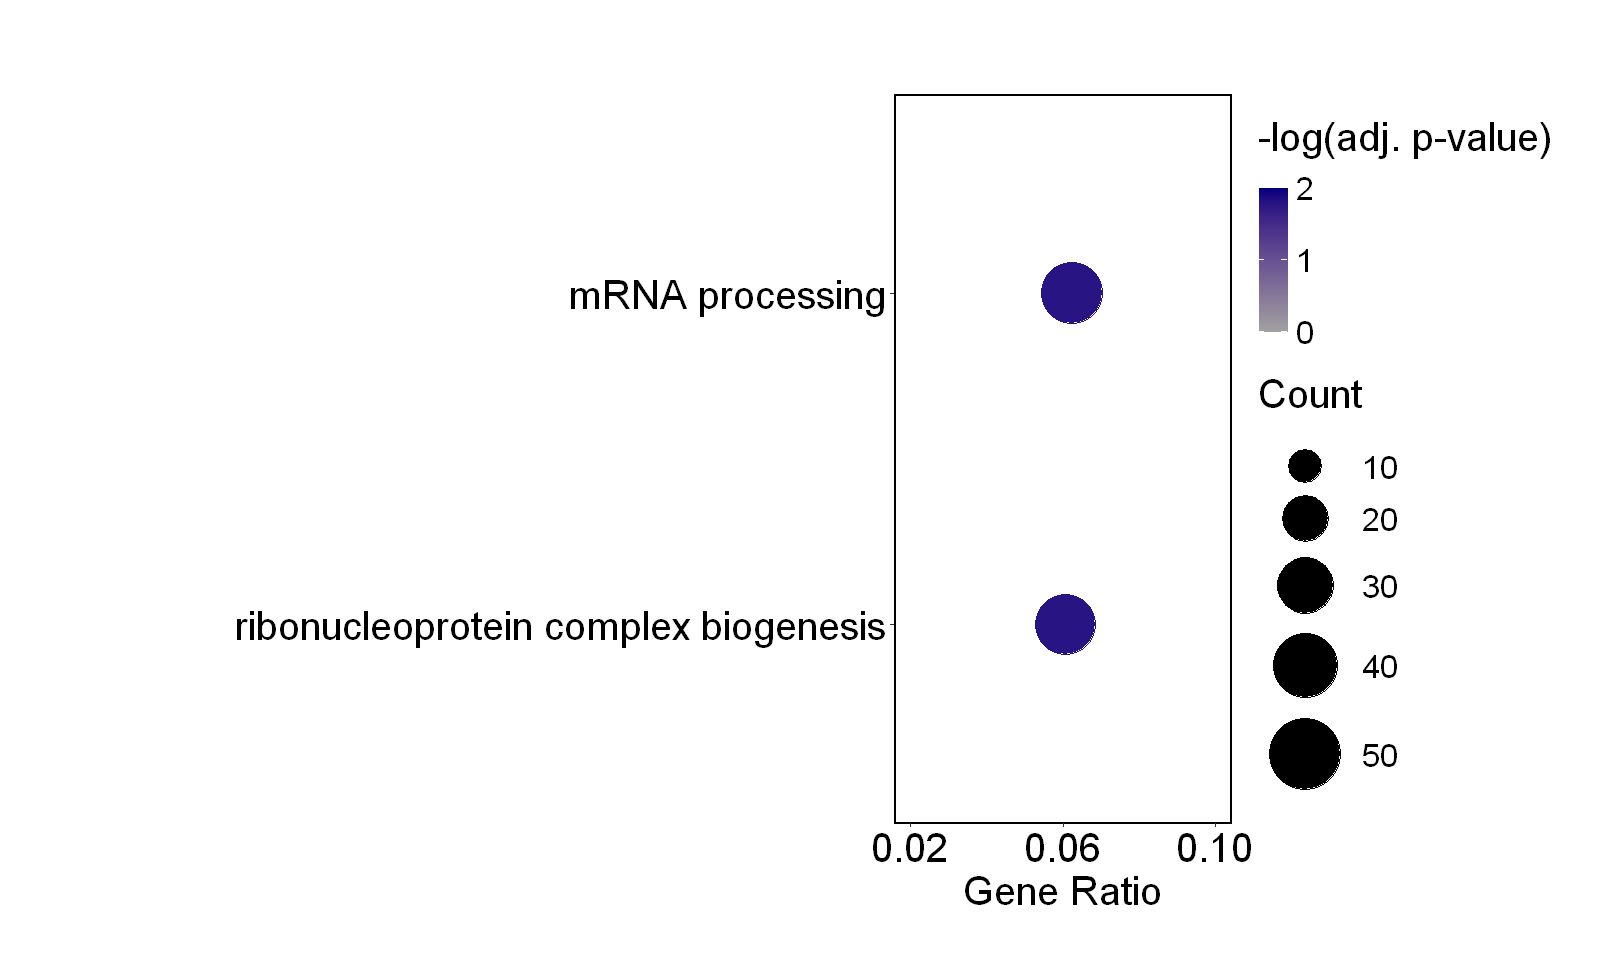

In [105]:
library(scales)
options(repr.plot.width = 13.5, repr.plot.height = 8)

go_data <- head(as.data.frame(chemogenetic_go_sensitisation), 2)

go_data$GeneRatio <- sapply(strsplit(as.character(go_data$GeneRatio), "/"), function(x) as.numeric(x[1]) / as.numeric(x[2]))

ggplot(go_data, aes(x = GeneRatio, y = reorder(Description, GeneRatio), size = Count, color = -log10(p.adjust))) +
  geom_point() +
  
  scale_color_gradient(low = "#A1A1A1", high = "#00007F", limits = c(0, 2), 
                       breaks = c(0, 1,2)) + 
  
  scale_x_continuous(limits = c(0.02, 0.1), breaks = seq(0.02, 0.1, by = 0.04),
                     labels = scales::label_number(accuracy = 0.01)) + 
  
  theme_classic() +
  
  theme(panel.border = element_rect(color = "black", fill = NA, linewidth = 1),  
        legend.title = element_text(margin = margin(b = 20), size = 24, color = "black"),  
        legend.spacing = unit(0.5, "cm"),  
        text = element_text(family = "sans", size = 24, color = "black"),
        
        axis.text = element_text(family = "sans", size = 24, color = "black"),
        
        axis.title.y = element_text(margin = margin(r = 20), size = 24, color = "black"),  
        
        plot.title = element_text(family = "sans", size = 24, face = "bold", color = "black"),
        
        plot.margin = margin(1, 1, 1, 3, "cm")) + 
    
  labs(title = "",
       x = "Gene Ratio", 
       y = "",
       color = "-log(adj. p-value)") +
  
  scale_size_continuous(range = c(1, 20), limits = c(1,50), breaks = c(10, 20, 30, 40, 50))

ggsave("chemogenetic_go_sensitisation.jpeg", width = 13.5, height = 8, dpi = 300)


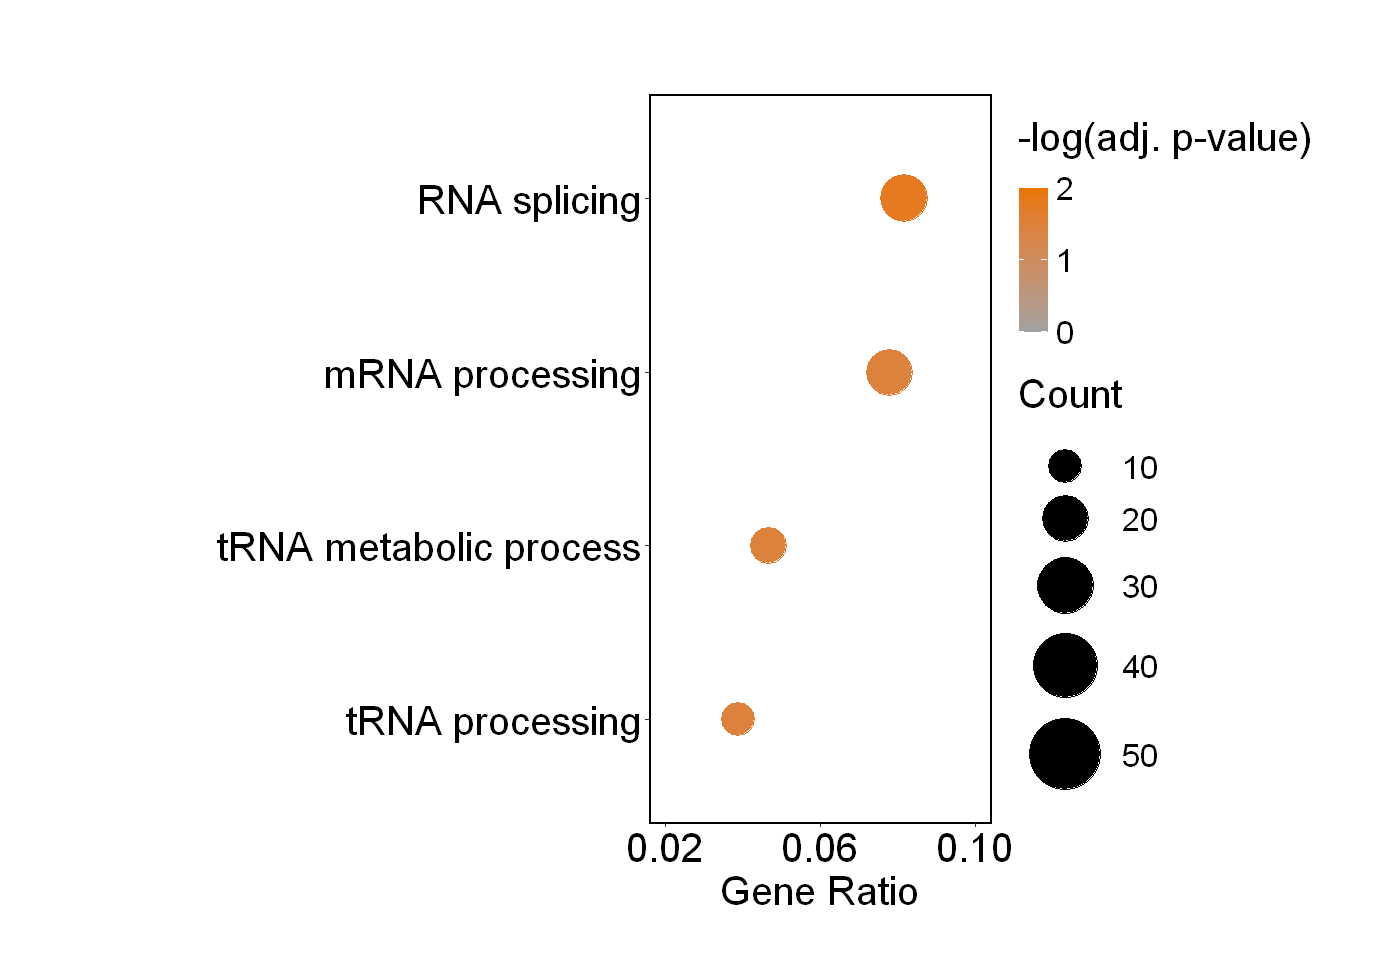

In [107]:
library(scales)
options(repr.plot.width = 11.5, repr.plot.height = 8)

go_data <- head(as.data.frame(chemogenetic_go_resistance), 4)

go_data$GeneRatio <- sapply(strsplit(as.character(go_data$GeneRatio), "/"), function(x) as.numeric(x[1]) / as.numeric(x[2]))

ggplot(go_data, aes(x = GeneRatio, y = reorder(Description, GeneRatio), size = Count, color = -log10(p.adjust))) +
  geom_point() +
  
  scale_color_gradient(low = "#A1A1A1", high = "#EA7500", limits = c(0, 2), 
                       breaks = c(0, 1,2)) +  
  
  scale_x_continuous(limits = c(0.02, 0.1), breaks = seq(0.02, 0.1, by = 0.04),
                     labels = scales::label_number(accuracy = 0.01)) +  # Ensure decimal form with 2 decimal places
  
  theme_classic() +
  
  theme(panel.border = element_rect(color = "black", fill = NA, linewidth = 1),  
        legend.title = element_text(margin = margin(b = 20), size = 24, color = "black"), 
        legend.spacing = unit(0.5, "cm"),  
        text = element_text(family = "sans", size = 24, color = "black"),
        
        axis.text = element_text(family = "sans", size = 24, color = "black"),
        
        axis.title.y = element_text(margin = margin(r = 20), size = 24, color = "black"),  
        
        plot.title = element_text(family = "sans", size = 24, face = "bold", color = "black"),
        
        plot.margin = margin(1, 1, 1, 3, "cm")) +  
    
  labs(title = "",
       x = "Gene Ratio", 
       y = "",
       color = "-log(adj. p-value)") +
  
  scale_size_continuous(range = c(1, 20), limits = c(1,50), breaks = c(10, 20, 30, 40, 50))

ggsave("chemogenetic_go_resistance.jpeg", width = 11.5, height = 8, dpi = 300)


Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
"font family not found in Windows font database"
Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
"font family not found in Windows font database"
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
"font family not found in Windows font database"
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
"font family not found in Windows font database"
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
"font family not found in Windows font database"
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
"font family not found in Windows font database"
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
"font family not found in Windows font database"
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
"font family not

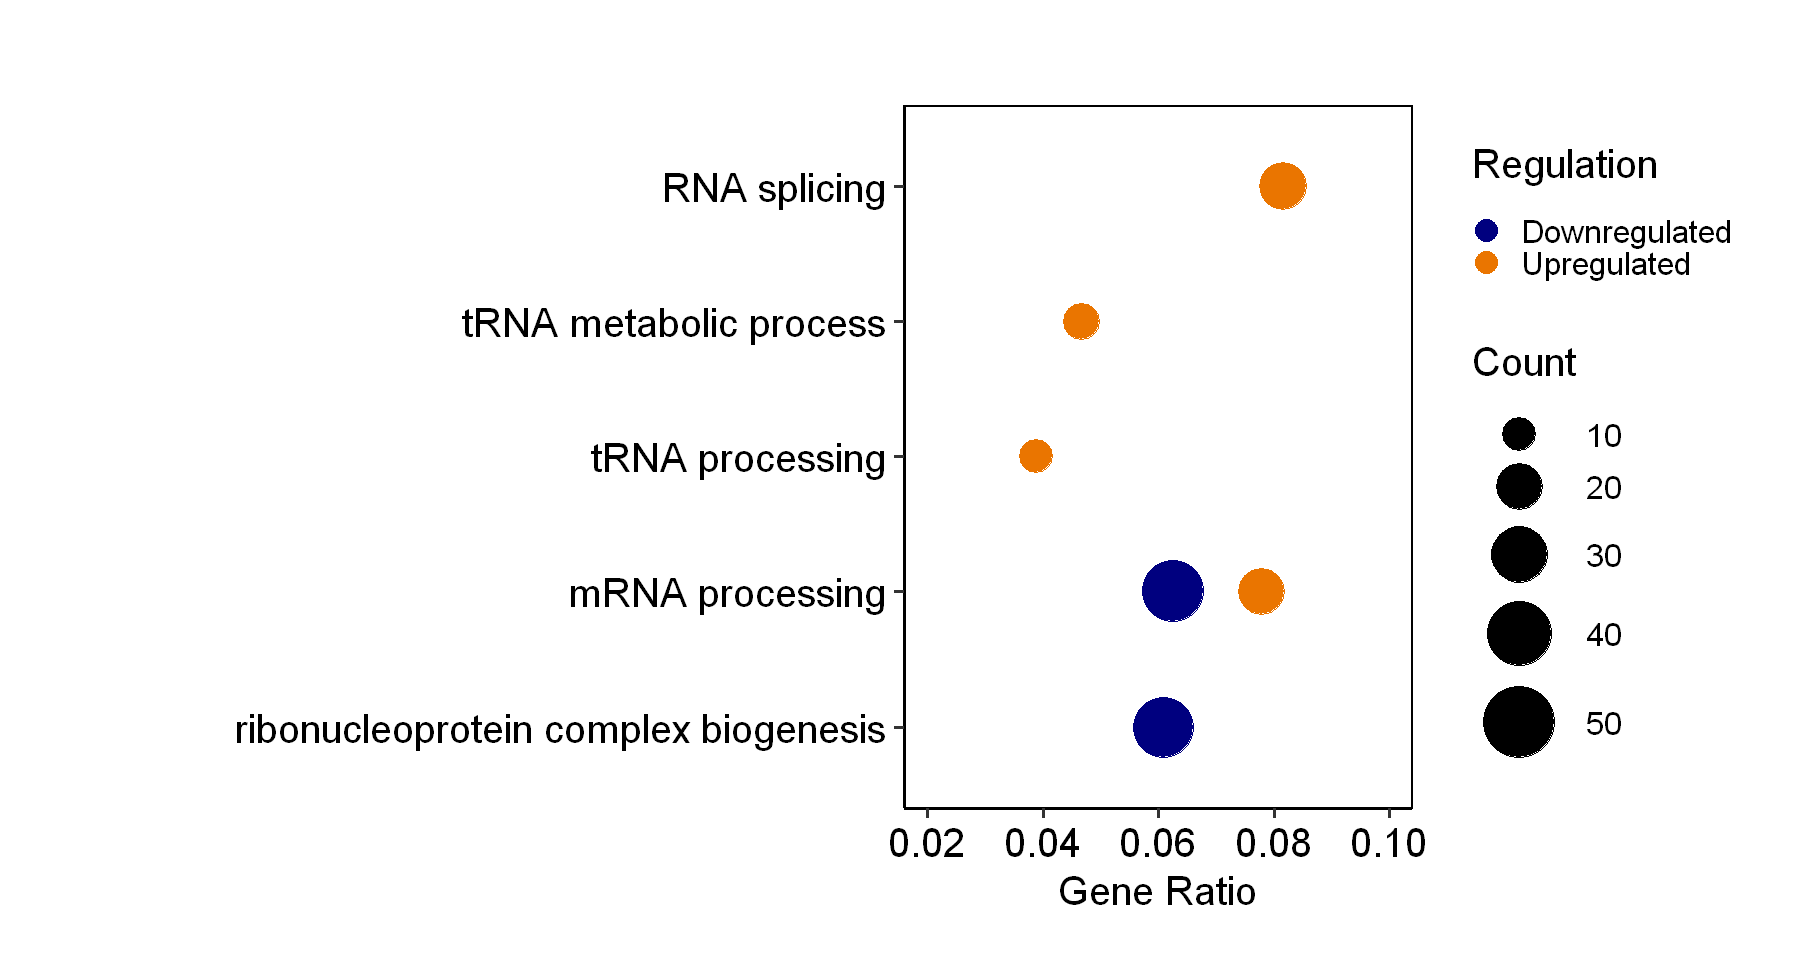

In [11]:
library(ggplot2)
library(scales)
options(repr.plot.width = 15, repr.plot.height = 8)

upregulated_data <- head(as.data.frame(chemogenetic_go_resistance), 4)
downregulated_data <- head(as.data.frame(chemogenetic_go_sensitisation), 2)

upregulated_data$GeneRatio <- sapply(strsplit(as.character(upregulated_data$GeneRatio), "/"), function(x) as.numeric(x[1]) / as.numeric(x[2]))
downregulated_data$GeneRatio <- sapply(strsplit(as.character(downregulated_data$GeneRatio), "/"), function(x) as.numeric(x[1]) / as.numeric(x[2]))

upregulated_data$Regulation <- "Upregulated"
downregulated_data$Regulation <- "Downregulated"

combined_data <- rbind(upregulated_data, downregulated_data)

combined_data$Description <- factor(combined_data$Description, levels = rev(unique(c(upregulated_data$Description, downregulated_data$Description))))

ggplot(combined_data, aes(x = GeneRatio, y = Description, size = Count, color = Regulation)) +
  geom_point() +
  
  scale_color_manual(values = c("Upregulated" = "#EA7500", "Downregulated" = "#00007F")) +
  
  scale_x_continuous(limits = c(0.02, 0.1), breaks = seq(0.02, 0.1, by = 0.02),
                     labels = scales::label_number(accuracy = 0.01)) +
  
  theme_classic(base_size = 24) +
  
  theme(panel.border = element_rect(color = "black", fill = NA, linewidth = 1),  # Adds a black frame
        legend.title = element_text(margin = margin(b = 20), size = 24, color = "black"),  # Move the legend title down
        legend.spacing = unit(0.5, "cm"),  # Add space between the legend elements 
        text = element_text(family = "Arial", size = 24, color = "black"),  # Customize font for all text elements
        axis.text = element_text(family = "Arial", size = 24, color = "black"),  # Customize axis labels
        axis.title.y = element_text(margin = margin(r = 20), size = 24, color = "black"),  # Adjust y-axis title position
        plot.title = element_text(family = "Arial", size = 24, face = "bold", color = "black"),  # Customize plot title
        plot.margin = margin(1, 1, 1, 3, "cm")) +  # Adjust plot margin
    
  labs(title = "",
       x = "Gene Ratio", 
       y = "",
       color = "Regulation") +
  
  scale_size_continuous(range = c(1, 20), limits = c(1, 50), breaks = c(10, 20, 30, 40, 50)) +
  
  guides(color = guide_legend(override.aes = list(size = 6)))

ggsave("combined_go_sensitisation_resistance_cbar.jpeg", width = 15, height = 8, dpi = 300)


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
"font family not found in Windows font database"
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
"font family not found in Windows font database"
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
"font family not found in Windows font database"
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
"font family not found in Windows font database"
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
"font family not found in Windows font database"
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
"font family not found in Windows font database"
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
"font family not found in Windows font database"
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, 

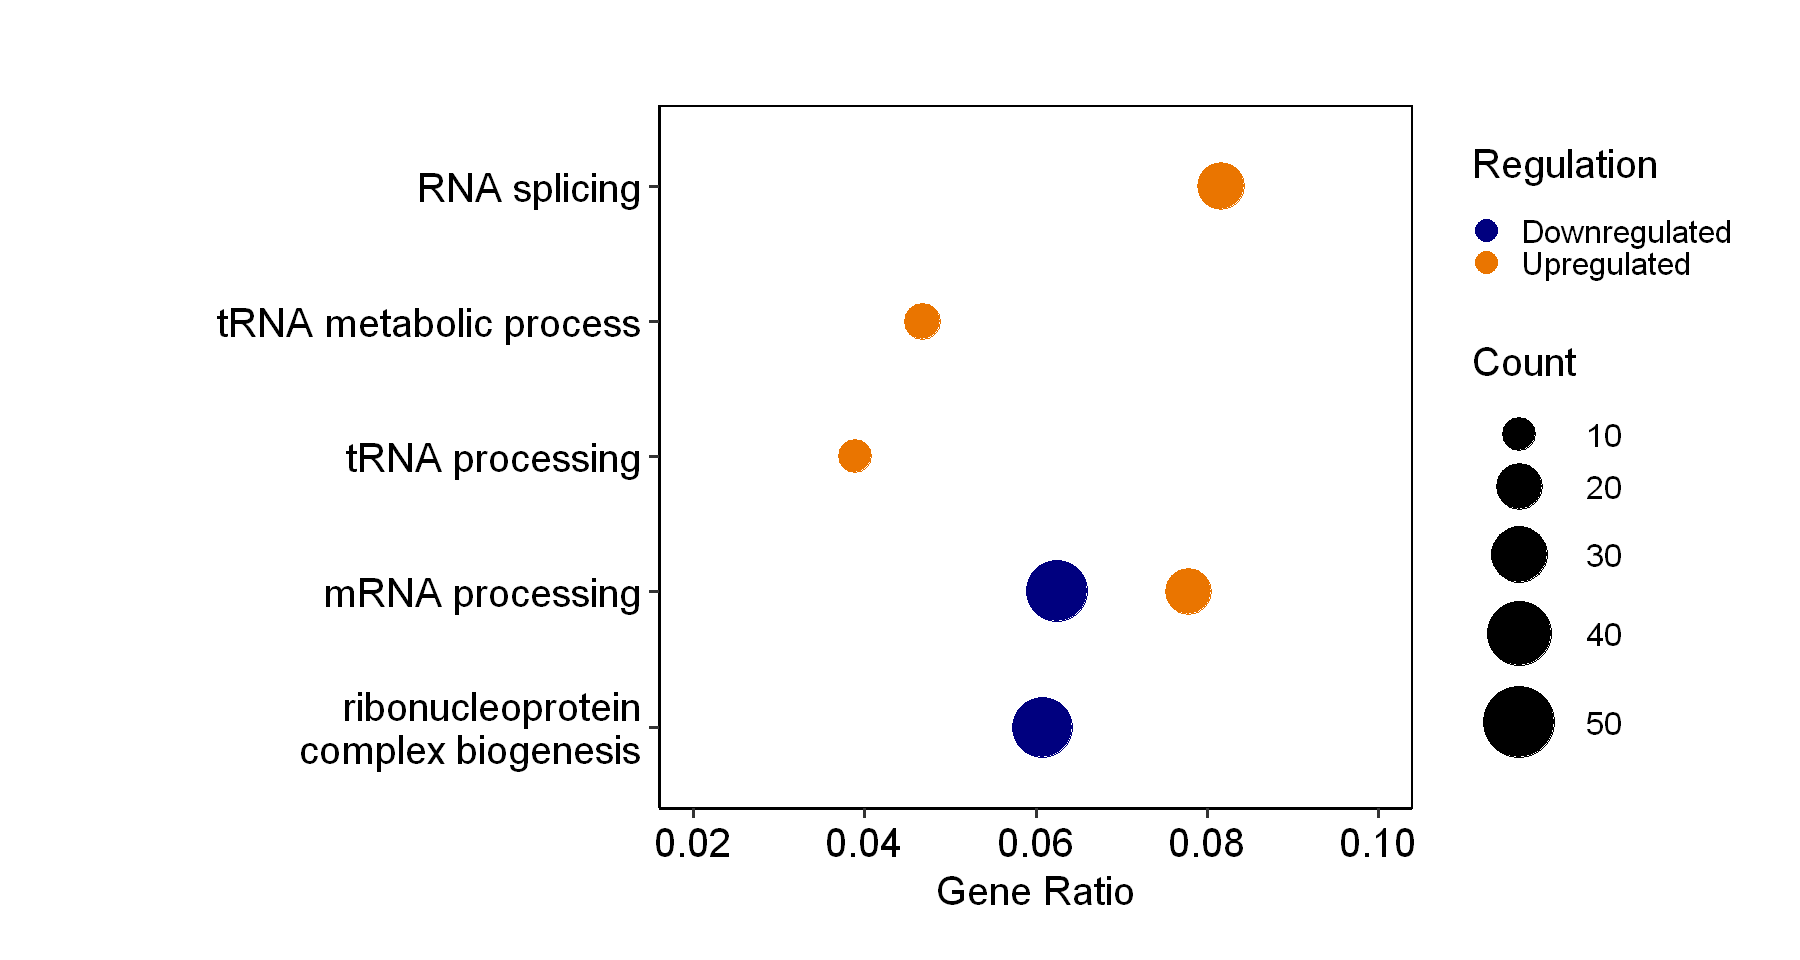

In [25]:
library(ggplot2)
library(scales)
library(stringr)  
options(repr.plot.width = 15, repr.plot.height = 8)

upregulated_data <- head(as.data.frame(chemogenetic_go_resistance), 4)
downregulated_data <- head(as.data.frame(chemogenetic_go_sensitisation), 2)

upregulated_data$GeneRatio <- sapply(strsplit(as.character(upregulated_data$GeneRatio), "/"),
                                     function(x) as.numeric(x[1]) / as.numeric(x[2]))
downregulated_data$GeneRatio <- sapply(strsplit(as.character(downregulated_data$GeneRatio), "/"),
                                       function(x) as.numeric(x[1]) / as.numeric(x[2]))

upregulated_data$Regulation <- "Upregulated"
downregulated_data$Regulation <- "Downregulated"

combined_data <- rbind(upregulated_data, downregulated_data)

combined_data$Description <- factor(combined_data$Description, 
                                    levels = rev(unique(c(upregulated_data$Description, downregulated_data$Description))))

p <- ggplot(combined_data, aes(x = GeneRatio, y = Description, size = Count, color = Regulation)) +
  geom_point() +
  
  scale_color_manual(values = c("Upregulated" = "#EA7500", "Downregulated" = "#00007F")) +
  
  scale_x_continuous(limits = c(0.02, 0.1), breaks = seq(0.02, 0.1, by = 0.02),
                     labels = scales::label_number(accuracy = 0.01)) +
  
  theme_classic(base_size = 24) +
  
  theme(panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
        legend.title = element_text(margin = margin(b = 20), size = 24, color = "black"),
        legend.spacing = unit(0.5, "cm"),
        text = element_text(family = "Arial", size = 24, color = "black"),
        axis.text = element_text(family = "Arial", size = 24, color = "black"),
        axis.title.y = element_text(margin = margin(r = 20), size = 24, color = "black"),
        plot.title = element_text(family = "Arial", size = 24, face = "bold", color = "black"),
        plot.margin = margin(1, 1, 1, 3, "cm")) +
  
  labs(title = "",
       x = "Gene Ratio", 
       y = "",
       color = "Regulation") +
  
  scale_size_continuous(range = c(1, 20), limits = c(1, 50), breaks = c(10, 20, 30, 40, 50)) +
  
  guides(color = guide_legend(override.aes = list(size = 6))) +
  
  scale_y_discrete(labels = function(x) str_wrap(x, width = 22))


plot(p)
ggsave("combined_go_sensitisation_resistance_cbar.jpeg", plot = p, width = 13, height = 8, dpi = 300)


In [25]:
upregulated_go_24hrs_df <- as.data.frame(upregulated_go_24hrs)

write.csv(upregulated_go_24hrs_df, file = "upregulated_go_24hrs_results.csv", row.names = FALSE)

cat("GO enrichment results have been saved as 'upregulated_go_24hrs_results.csv'\n")

upregulated_go_72hrs_df <- as.data.frame(upregulated_go_72hrs)

write.csv(upregulated_go_72hrs_df, file = "upregulated_go_72hrs_results.csv", row.names = FALSE)

cat("GO enrichment results have been saved as 'upregulated_go_72hrs_results.csv'\n")

upregulated_go_120hrs_df <- as.data.frame(upregulated_go_120hrs)

write.csv(upregulated_go_120hrs_df, file = "upregulated_go_120hrs_results.csv", row.names = FALSE)

cat("GO enrichment results have been saved as 'upregulated_go_120hrs_results.csv'\n")

#### DOWNREGULATED #####

downregulated_go_24hrs_df <- as.data.frame(downregulated_go_24hrs)

write.csv(downregulated_go_24hrs_df, file = "downregulated_go_24hrs_results.csv", row.names = FALSE)

cat("GO enrichment results have been saved as 'downregulated_go_24hrs_results.csv'\n")

downregulated_go_72hrs_df <- as.data.frame(downregulated_go_72hrs)

write.csv(downregulated_go_72hrs_df, file = "downregulated_go_72hrs_results.csv", row.names = FALSE)

cat("GO enrichment results have been saved as 'downregulated_go_72hrs_results.csv'\n")

downregulated_go_120hrs_df <- as.data.frame(downregulated_go_120hrs)

write.csv(downregulated_go_120hrs_df, file = "downregulated_go_120hrs_results.csv", row.names = FALSE)

cat("GO enrichment results have been saved as 'downregulated_go_120hrs_results.csv'\n")


GO enrichment results have been saved as 'upregulated_go_24hrs_results.csv'
GO enrichment results have been saved as 'upregulated_go_72hrs_results.csv'
GO enrichment results have been saved as 'upregulated_go_120hrs_results.csv'
GO enrichment results have been saved as 'downregulated_go_24hrs_results.csv'
GO enrichment results have been saved as 'downregulated_go_72hrs_results.csv'
GO enrichment results have been saved as 'downregulated_go_120hrs_results.csv'


In [27]:
chemogenetic_go_resistance <- as.data.frame(chemogenetic_go_resistance)

write.csv(chemogenetic_go_resistance, file = "chemogenetic_go_resistance.csv", row.names = FALSE)

cat("GO enrichment results have been saved as 'chemogenetic_go_resistance.csv'\n")

chemogenetic_go_sensitisation_df <- as.data.frame(chemogenetic_go_sensitisation)

write.csv(chemogenetic_go_sensitisation, file = "chemogenetic_go_sensitisation.csv", row.names = FALSE)

cat("GO enrichment results have been saved as 'chemogenetic_go_sensitisation.csv'\n")

GO enrichment results have been saved as 'chemogenetic_go_resistance.csv'
GO enrichment results have been saved as 'chemogenetic_go_sensitisation.csv'
